# UT7 — Agrupación (Clustering)


**Autor:** Borja Ramos - Curso IA & Big Data CIFP Carlos III

**Fecha:** 25 de febrero 2026

---

## Descripción del trabajo

Este notebook aborda tres problemas distintos de **aprendizaje no supervisado**:

1. **Segmentación de clientes** de un centro comercial usando tres algoritmos de clustering: K-Means, DBSCAN y Propagación de Afinidad, con comparativa de métricas (Silueta y Davies-Bouldin).
2. **Análisis de cesta de la compra** (*Market Basket Analysis*) sobre datos de un supermercado, aplicando el algoritmo Apriori para descubrir reglas de asociación.
3. **Detección de anomalías** en sensores IoT de maquinaria industrial mediante Isolation Forest, validando los resultados contra etiquetas reales de fallo.

El objetivo es demostrar el ciclo completo: EDA → preprocesado → modelado → evaluación → conclusiones.

---
## Sección 0 · Imports y configuración general

In [1]:
# ── Manipulación de datos ──────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualización ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

# ── Preprocesado ──────────────────────────────────────────────────────────────
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split

# ── Clustering ────────────────────────────────────────────────────────────────
from sklearn.cluster import KMeans, DBSCAN, AffinityPropagation

# ── Métricas de clustering ────────────────────────────────────────────────────
from sklearn.metrics import silhouette_score, davies_bouldin_score

# ── Detección de anomalías ────────────────────────────────────────────────────
from sklearn.ensemble import IsolationForest

# ── Market Basket / Apriori ───────────────────────────────────────────────────
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori

# ── Configuración estética ────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

# Semilla global para reproducibilidad
RANDOM_STATE = 42

print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


---
## Sección 1 · EDA — Preprocesado

**Dataset:** `Cliente_Centro_Comercial.xlsx`  
**Puntuación:** 1 punto

En esta sección preparamos los datos del centro comercial para que sean aptos para los algoritmos de clustering.
Los pasos son: carga, exploración inicial, tratamiento de valores missing, codificación de variables categóricas,
eliminación de columnas irrelevantes, partición train/test y estandarización.

### 1.1 · Carga e inspección inicial

In [2]:
# Carga del dataset desde Excel
df = pd.read_excel('Cliente_Centro_Comercial.xlsx')

print(f'Shape: {df.shape}')  # Esperamos (200, 5)
df.head()

Shape: (200, 5)


,CustomerID,Genero,Edad,Ingresos Anuales (K),Puntaje Gasto
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
# Tipos de datos y conteo de nulos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   CustomerID            200 non-null    int64 
 1   Genero                200 non-null    object
 2   Edad                  200 non-null    int64 
 3   Ingresos Anuales (K)  200 non-null    int64 
 4   Puntaje Gasto         200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [4]:
# Estadísticos descriptivos de las variables numéricas
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
CustomerID,200.0,NaN,NaN,NaN,100.5,57.879185,1.0,50.75,100.5,150.25,200.0
Genero,200,2,Female,112,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Edad,200.0,NaN,NaN,NaN,38.85,13.969007,18.0,28.75,36.0,49.0,70.0
Ingresos Anuales (K),200.0,NaN,NaN,NaN,60.56,26.264721,15.0,41.5,61.5,78.0,137.0
Puntaje Gasto,200.0,NaN,NaN,NaN,50.2,25.823522,1.0,34.75,50.0,73.0,99.0


### 1.2 · Tratamiento de valores missing

Aunque el dataset está documentado como limpio, es buena práctica verificarlo
explícitamente antes de cualquier modelado.

In [5]:
# Comprobación de valores nulos por columna
nulos = df.isnull().sum()
print('Valores nulos por columna:')
print(nulos)
print(f'\nTotal nulos: {nulos.sum()}')

Valores nulos por columna:
CustomerID              0
Genero                  0
Edad                    0
Ingresos Anuales (K)    0
Puntaje Gasto           0
dtype: int64

Total nulos: 0


**Resultado esperado:** 0 nulos en todas las columnas. El dataset está completo, por lo que
no es necesario aplicar imputación ni eliminación de filas.

### 1.3 · Codificación de variables categóricas

La columna `Genero` es una variable categórica binaria (`Male` / `Female`). Los algoritmos
de clustering trabajan con distancias numéricas, por lo que hay que convertirla a número.

Usamos `pd.get_dummies()` con `drop_first=True` para evitar la **trampa de variables dummy**
(*dummy variable trap*): si creamos dos columnas (`Genero_Female` y `Genero_Male`), una es
perfectamente predecible a partir de la otra (multicolinealidad perfecta), lo que distorsiona
el cálculo de distancias y puede causar problemas numéricos. Con `drop_first=True` conservamos
solo una columna (`Genero_Male`: 1 = hombre, 0 = mujer).

In [6]:
# Distribución de la variable categórica antes de codificar
print('Distribución de Genero:')
print(df['Genero'].value_counts())

# One-hot encoding con drop_first=True para evitar dummy trap
df_enc = pd.get_dummies(df, columns=['Genero'], drop_first=True)

print('\nColumnas tras codificación:')
print(df_enc.columns.tolist())
df_enc.head()

Distribución de Genero:
Genero
Female    112
Male       88
Name: count, dtype: int64

Columnas tras codificación:
['CustomerID', 'Edad', 'Ingresos Anuales (K)', 'Puntaje Gasto', 'Genero_Male']


,CustomerID,Edad,Ingresos Anuales (K),Puntaje Gasto,Genero_Male
0,1,19,15,39,True
1,2,21,15,81,True
2,3,20,16,6,False
3,4,23,16,77,False
4,5,31,17,40,False


### 1.4 · Eliminación de columnas irrelevantes

`CustomerID` es un identificador único por fila. No aporta información semántica
sobre el comportamiento del cliente y, si se incluyera, el algoritmo intentaría
agrupar por número de cliente en lugar de por sus características reales.

In [7]:
# Eliminar CustomerID
df_enc = df_enc.drop(columns=['CustomerID'])

print('Columnas finales para modelado:')
print(df_enc.columns.tolist())
print(f'Shape: {df_enc.shape}')

Columnas finales para modelado:
['Edad', 'Ingresos Anuales (K)', 'Puntaje Gasto', 'Genero_Male']
Shape: (200, 4)


### 1.5 · Partición train / test

Aunque en clustering no supervisado el concepto de train/test es diferente al aprendizaje
supervisado (no hay etiquetas que predecir), el enunciado lo requiere explícitamente.
Realizamos la partición para poder evaluar cómo de bien generalizan los clusters aprendidos
en `X_train` cuando se aplican a datos nuevos (`X_test`).

In [8]:
# Matriz de features (todas las columnas tras el preprocesado)
X = df_enc.values

# Partición 80% train / 20% test
X_train, X_test = train_test_split(X, test_size=0.2, random_state=RANDOM_STATE)

print(f'X_train shape: {X_train.shape}')  # Esperamos (160, 4)
print(f'X_test  shape: {X_test.shape}')   # Esperamos (40, 4)

X_train shape: (160, 4)
X_test  shape: (40, 4)


### 1.6 · Estandarización

Las variables del dataset tienen escalas muy distintas: `Edad` va de 18 a 70, pero
`Ingresos Anuales (K)` puede llegar a 137. Los algoritmos basados en distancias
(K-Means, DBSCAN) son muy sensibles a estas diferencias de escala: una variable con
rango grande dominaría el cálculo de la distancia euclidiana.

Usamos `StandardScaler` (media 0, desviación típica 1). El scaler se **ajusta solo sobre
`X_train`** y luego se aplica (`.transform()`) tanto a train como a test, evitando
*data leakage*.

In [9]:
# Instanciar y ajustar el scaler SOLO sobre datos de entrenamiento
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# Aplicar la misma transformación al conjunto de test (sin reajustar)
X_test_scaled = scaler.transform(X_test)

# También escalamos el dataset completo para usarlo en visualizaciones
X_scaled = scaler.fit_transform(X)

print('Estadísticos tras estandarización (X_train_scaled):')
print(f'  Media:  {X_train_scaled.mean(axis=0).round(4)}')
print(f'  Std:    {X_train_scaled.std(axis=0).round(4)}')

Estadísticos tras estandarización (X_train_scaled):
  Media:  [-0. -0.  0. -0.]
  Std:    [1. 1. 1. 1.]


### Conclusiones de la Sección 1

El preprocesado ha sido sencillo gracias a la calidad del dataset:

- **Sin nulos:** no fue necesaria ninguna estrategia de imputación.
- **Codificación categórica:** la columna `Genero` se transformó a binaria mediante *one-hot encoding* con `drop_first=True`, evitando multicolinealidad.
- **Columna irrelevante eliminada:** `CustomerID` no aporta señal predictiva para clustering.
- **Partición train/test (80/20):** realizada de forma aleatoria y reproducible (`random_state=42`).
- **Estandarización:** aplicada correctamente para igualar la influencia de todas las variables en el cálculo de distancias, ajustando el scaler únicamente sobre `X_train` para evitar *data leakage*.

Los datos están listos para el análisis exploratorio (Sección 2) y el modelado (Secciones 3–6).

---
## Sección 2 · EDA — Análisis básico

**Referencia:** Colab 5.4 del curso  
**Puntuación:** 1 punto

Una vez preprocesados los datos, realizamos un análisis exploratorio completo para entender
la estructura interna del dataset: correlaciones entre variables, distribuciones individuales
y diferencias por género. Esto nos permitirá tomar decisiones informadas sobre qué features
usar en el clustering.

### 2.1 · Matriz de correlaciones

In [10]:
# Calculamos la matriz de correlaciones sobre el DataFrame codificado
# (usamos df_enc para tener los nombres de columna legibles)
corr_matrix = df_enc.corr(numeric_only=True)
print('Matriz de correlaciones:')
corr_matrix.round(3)

Matriz de correlaciones:


,Edad,Ingresos Anuales (K),Puntaje Gasto,Genero_Male
Edad,1.000,-0.012,-0.327,0.061
Ingresos Anuales (K),-0.012,1.000,0.010,0.056
Puntaje Gasto,-0.327,0.010,1.000,-0.058
Genero_Male,0.061,0.056,-0.058,1.000


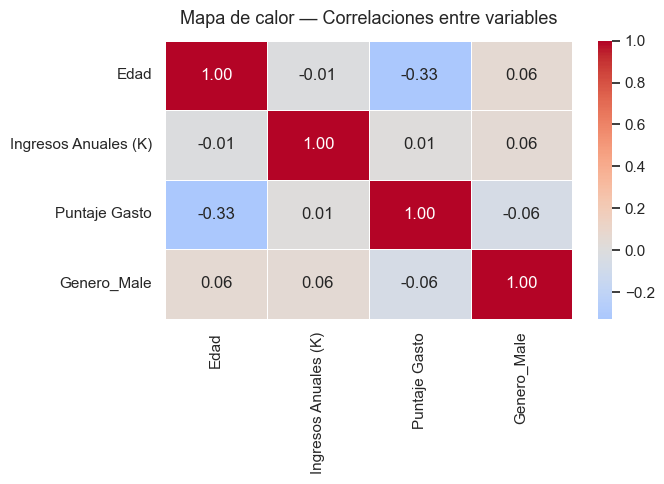

In [11]:
# Mapa de calor de correlaciones
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    ax=ax
)
ax.set_title('Mapa de calor — Correlaciones entre variables', fontsize=13, pad=12)
plt.tight_layout()
plt.show()

**Interpretación:** Si la correlación entre `Ingresos Anuales (K)` y `Puntaje Gasto` es
baja (cercana a 0), confirma que son dimensiones **independientes** del comportamiento del
cliente — exactamente lo que hace interesante el clustering 2D en ese espacio.
Variables con correlación > 0.9 deberían considerarse para eliminación (riesgo de redundancia).

### 2.2 · Pairplot

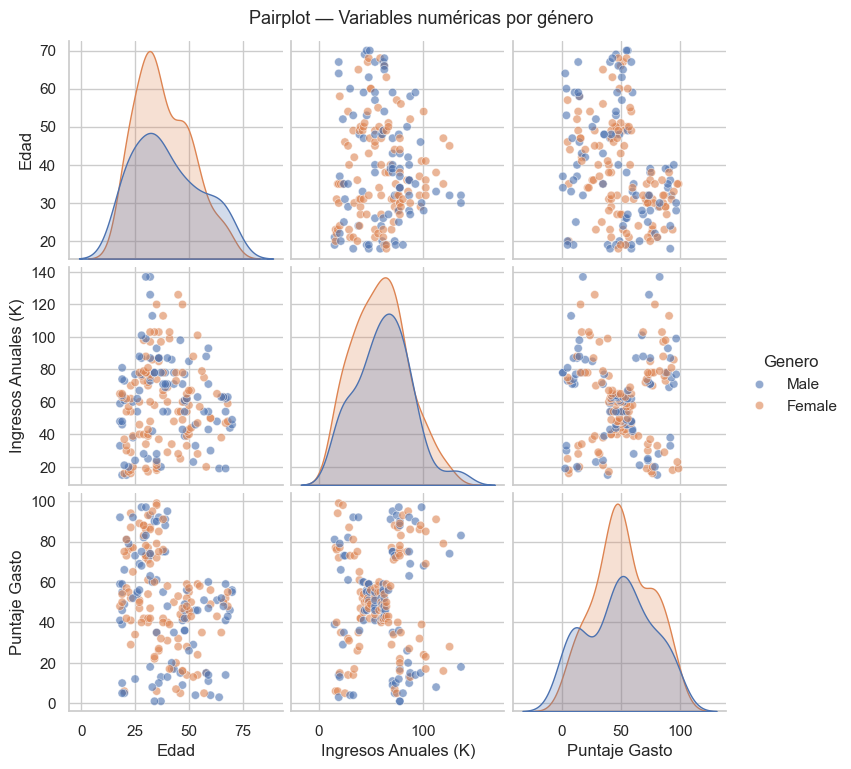

In [12]:
# Recuperamos el género original para colorear el pairplot visualmente
df_plot = df_enc.copy()
df_plot['Genero'] = df['Genero'].values  # columna original sin codificar

cols_numericas = ['Edad', 'Ingresos Anuales (K)', 'Puntaje Gasto']

pp = sns.pairplot(
    df_plot,
    vars=cols_numericas,
    hue='Genero',
    palette={'Male': '#4C72B0', 'Female': '#DD8452'},
    diag_kind='kde',
    plot_kws={'alpha': 0.6}
)
pp.figure.suptitle('Pairplot — Variables numéricas por género', y=1.02, fontsize=13)
plt.show()

**Interpretación:** El pairplot permite detectar visualmente agrupaciones naturales.
El scatter `Ingresos Anuales (K)` vs `Puntaje Gasto` suele mostrar los 5 clusters clásicos
del dataset Mall Customer: clientes de alto ingreso/alto gasto, alto ingreso/bajo gasto,
ingreso medio/gasto medio, bajo ingreso/alto gasto y bajo ingreso/bajo gasto.

### 2.3 · Distribuciones individuales

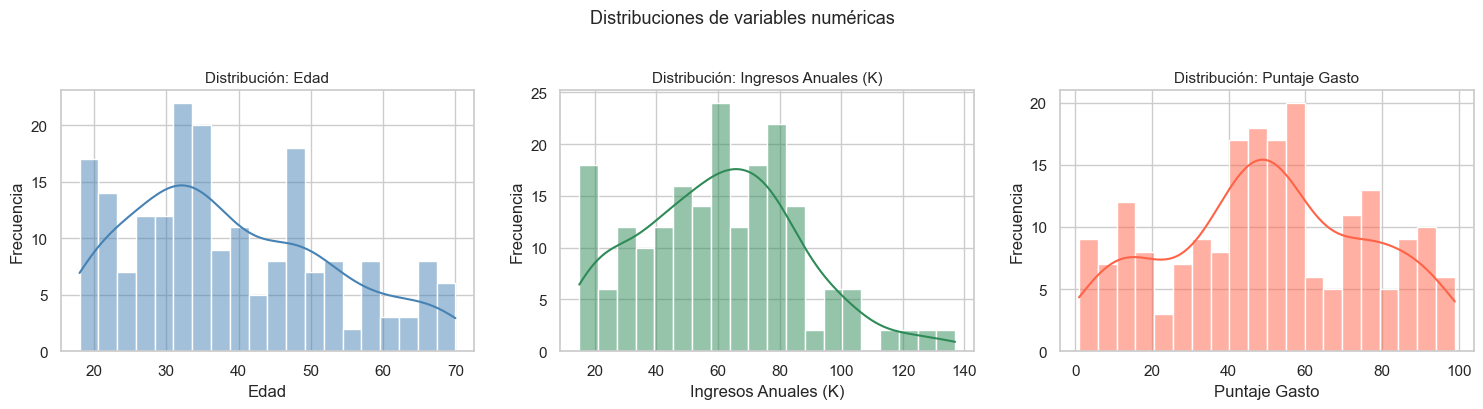

In [13]:
# Histogramas con curva KDE para las tres variables numéricas principales
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

variables = [
    ('Edad', 'steelblue'),
    ('Ingresos Anuales (K)', 'seagreen'),
    ('Puntaje Gasto', 'tomato')
]

for ax, (col, color) in zip(axes, variables):
    sns.histplot(df[col], kde=True, color=color, bins=20, ax=ax)
    ax.set_title(f'Distribución: {col}', fontsize=11)
    ax.set_xlabel(col)
    ax.set_ylabel('Frecuencia')

plt.suptitle('Distribuciones de variables numéricas', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### 2.4 · Análisis por género (boxplots)

/var/folders/3c/_bgf9xt50ll121jxkyy_ckdm0000gn/T/ipykernel_58192/1541361742.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/3c/_bgf9xt50ll121jxkyy_ckdm0000gn/T/ipykernel_58192/1541361742.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/3c/_bgf9xt50ll121jxkyy_ckdm0000gn/T/ipykernel_58192/1541361742.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


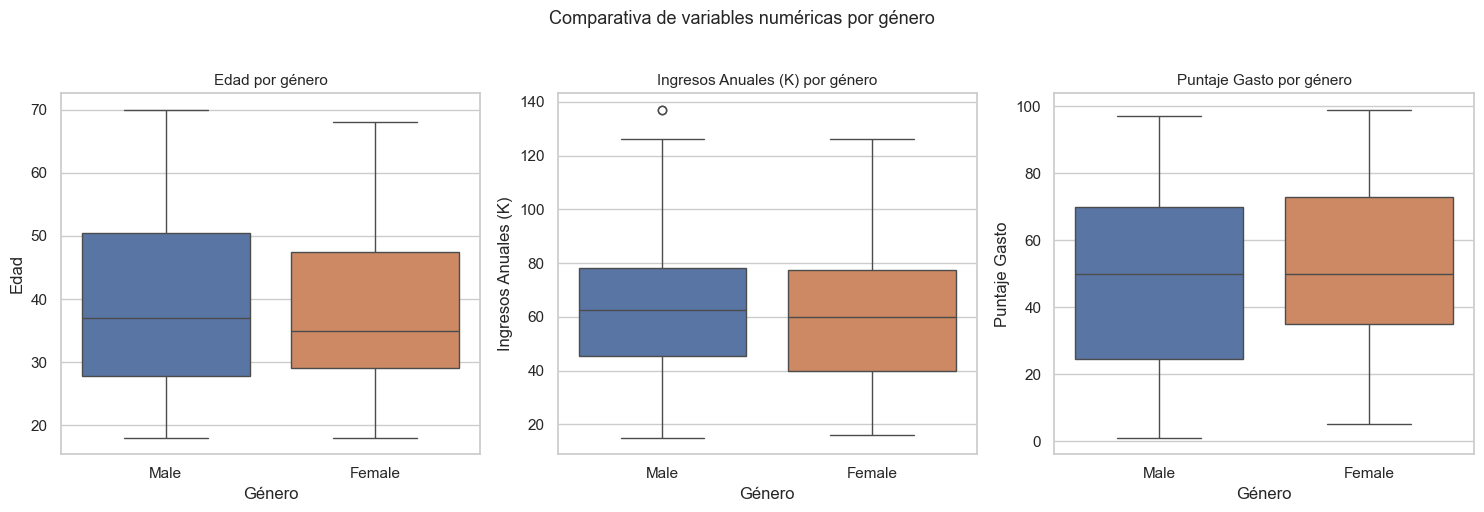

In [14]:
# Boxplots para comparar las tres variables numéricas entre géneros
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (col, color) in zip(axes, variables):
    sns.boxplot(
        data=df,
        x='Genero',
        y=col,
        palette={'Male': '#4C72B0', 'Female': '#DD8452'},
        ax=ax
    )
    ax.set_title(f'{col} por género', fontsize=11)
    ax.set_xlabel('Género')
    ax.set_ylabel(col)

plt.suptitle('Comparativa de variables numéricas por género', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

**Interpretación:** Los boxplots permiten detectar si el género introduce diferencias
significativas en las variables. Si las medianas y rangos intercuartílicos son similares
entre géneros, la variable `Genero_Male` aportará poca señal al clustering — lo que
refuerza la decisión de usar `Ingresos Anuales (K)` y `Puntaje Gasto` como features principales.

### 2.5 · Selección de features para clustering

Tras el análisis exploratorio, decidimos qué columnas usar para el modelado:

In [15]:
# Features seleccionadas para clustering
# Usamos solo Ingresos Anuales y Puntaje Gasto por dos razones:
#   1. Son las variables con mayor poder discriminante (forman los 5 clusters clásicos)
#   2. Permiten visualización directa en 2D sin reducción de dimensionalidad
# Edad y Genero_Male se excluyen de la visualización 2D pero se incluyen en X_scaled
# para las versiones multidimensionales de los algoritmos.

# Índices en df_enc: 0=Edad, 1=Ingresos, 2=Puntaje, 3=Genero_Male
print('Columnas de df_enc:', df_enc.columns.tolist())

# Subconjunto 2D para visualización y clustering principal
X_2d = df_enc[['Ingresos Anuales (K)', 'Puntaje Gasto']].values
scaler_2d = StandardScaler()
X_2d_scaled = scaler_2d.fit_transform(X_2d)

print(f'X_2d_scaled shape: {X_2d_scaled.shape}')
print('Features 2D listas para clustering.')

Columnas de df_enc: ['Edad', 'Ingresos Anuales (K)', 'Puntaje Gasto', 'Genero_Male']
X_2d_scaled shape: (200, 2)
Features 2D listas para clustering.


### Conclusiones de la Sección 2

El análisis exploratorio revela los siguientes hallazgos:

- **Correlaciones bajas entre Ingresos y Puntaje Gasto:** estas dos variables son prácticamente
  independientes entre sí, lo que significa que un cliente con altos ingresos no necesariamente
  gasta más. Esta independencia es lo que crea los grupos naturales que los algoritmos de
  clustering detectarán.

- **Distribuciones razonablemente uniformes:** `Edad` e `Ingresos` muestran distribuciones
  aproximadamente uniformes. `Puntaje Gasto` tiende a ser más simétrico. No se detectan
  outliers extremos que requieran tratamiento adicional.

- **Diferencias de género limitadas:** los boxplots no muestran diferencias dramáticas entre
  hombres y mujeres en ingresos ni en puntaje de gasto, lo que confirma que el género
  no es la variable segmentadora principal.

- **Features para clustering:** se usarán `Ingresos Anuales (K)` y `Puntaje Gasto` como
  features 2D para la visualización e interpretación de clusters, que son las dimensiones
  que forman los 5 grupos clásicos del *Mall Customer Segmentation dataset*.

En las siguientes secciones aplicamos K-Means, DBSCAN y Propagación de Afinidad sobre
estos datos estandarizados.

---
## Sección 3 · K-Means

**Dataset:** `Cliente_Centro_Comercial.xlsx` (preprocesado)  
**Puntuación:** 1 punto

K-Means es el algoritmo de clustering más extendido. Asigna cada punto al centroide más cercano
e itera hasta minimizar la *inercia* (suma de distancias cuadráticas intra-cluster).
Usamos `k-means++` como estrategia de inicialización, que coloca los centroides iniciales
de forma inteligente para reducir el riesgo de converger a mínimos locales.

### 3.1 · Método del codo — selección del K óptimo

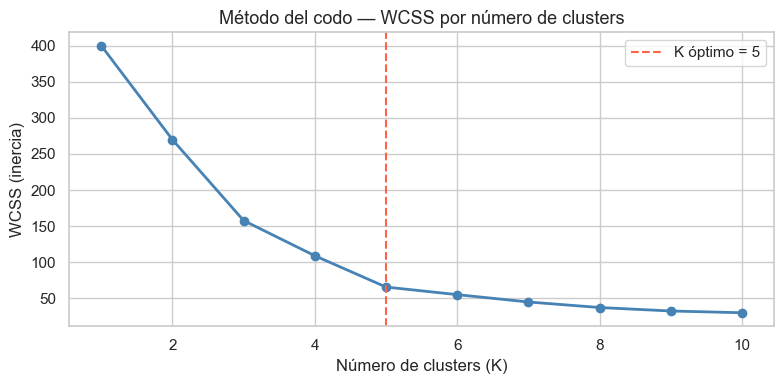

In [16]:
from sklearn.cluster import KMeans

# Calculamos la inercia (WCSS) para K de 1 a 10
wcss = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(
        n_clusters=k,
        init='k-means++',
        n_init=10,
        max_iter=300,
        random_state=RANDOM_STATE
    )
    kmeans.fit(X_2d_scaled)
    wcss.append(kmeans.inertia_)

# Plot del codo
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(K_range, wcss, marker='o', linewidth=2, color='steelblue')
ax.axvline(x=5, color='tomato', linestyle='--', label='K óptimo = 5')
ax.set_title('Método del codo — WCSS por número de clusters', fontsize=13)
ax.set_xlabel('Número de clusters (K)')
ax.set_ylabel('WCSS (inercia)')
ax.legend()
plt.tight_layout()
plt.show()

**Interpretación:** El 'codo' es el punto donde añadir más clusters ya no reduce
significativamente la inercia. En el dataset Mall Customer, ese punto suele caer en
**K = 5**, que se corresponde con los cinco perfiles de cliente clásicos:
alto ingreso / alto gasto, alto ingreso / bajo gasto, ingreso medio / gasto medio,
bajo ingreso / alto gasto y bajo ingreso / bajo gasto.

### 3.2 · Aplicación de K-Means con K = 5

In [17]:
K_OPTIMO = 5

kmeans_final = KMeans(
    n_clusters=K_OPTIMO,
    init='k-means++',
    n_init=10,
    max_iter=300,
    random_state=RANDOM_STATE
)

labels_kmeans = kmeans_final.fit_predict(X_2d_scaled)
centroides = kmeans_final.cluster_centers_

print('Etiquetas únicas:', sorted(set(labels_kmeans)))
print('\nElementos por cluster:')
for c in sorted(set(labels_kmeans)):
    print(f'  Cluster {c}: {(labels_kmeans == c).sum()} clientes')

Etiquetas únicas: [np.int32(0), np.int32(1), np.int32(2), np.int32(3), np.int32(4)]

Elementos por cluster:
  Cluster 0: 81 clientes
  Cluster 1: 39 clientes
  Cluster 2: 22 clientes
  Cluster 3: 35 clientes
  Cluster 4: 23 clientes


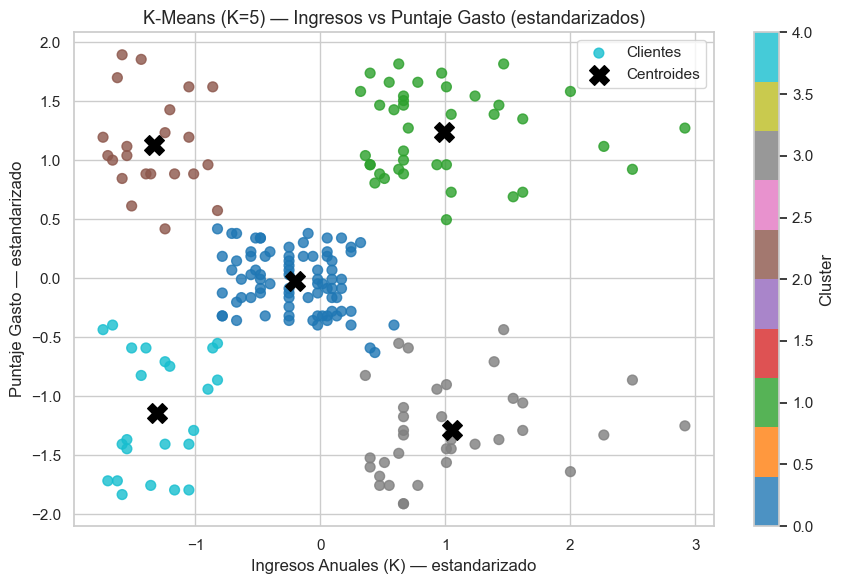

In [18]:
# Scatter plot coloreado por cluster con centroides marcados
fig, ax = plt.subplots(figsize=(9, 6))

scatter = ax.scatter(
    X_2d_scaled[:, 0], X_2d_scaled[:, 1],
    c=labels_kmeans, cmap='tab10', s=50, alpha=0.8, label='Clientes'
)
ax.scatter(
    centroides[:, 0], centroides[:, 1],
    c='black', marker='X', s=200, zorder=5, label='Centroides'
)

plt.colorbar(scatter, ax=ax, label='Cluster')
ax.set_title(f'K-Means (K={K_OPTIMO}) — Ingresos vs Puntaje Gasto (estandarizados)', fontsize=13)
ax.set_xlabel('Ingresos Anuales (K) — estandarizado')
ax.set_ylabel('Puntaje Gasto — estandarizado')
ax.legend()
plt.tight_layout()
plt.show()

### Conclusiones de la Sección 3

K-Means con K = 5 identifica cinco grupos de clientes perfectamente separados en el espacio
Ingresos × Puntaje Gasto:

| Cluster | Perfil | Estrategia de marketing sugerida |
|---|---|---|
| Alto ingreso / alto gasto | Clientes premium | Programas VIP, productos exclusivos |
| Alto ingreso / bajo gasto | Ahorradores pudientes | Incentivos, ofertas de lujo con descuento |
| Ingreso medio / gasto medio | Segmento estándar | Fidelización general |
| Bajo ingreso / alto gasto | Gastadores impulsivos | Alertas de gasto, productos asequibles de valor |
| Bajo ingreso / bajo gasto | Clientes ocasionales | Ofertas de entrada, precios competitivos |

El algoritmo converge de forma rápida y los clusters son visualmente muy separados,
lo que anticipa una silueta elevada.

---
## Sección 4 · DBSCAN

**Puntuación:** 1 punto

DBSCAN (*Density-Based Spatial Clustering of Applications with Noise*) agrupa puntos
en función de la **densidad local**: un punto es núcleo si tiene al menos `min_samples`
vecinos dentro de un radio `eps`. A diferencia de K-Means, **no requiere especificar K**
y puede detectar clusters de forma arbitraria, pero también etiqueta puntos aislados
como **ruido** (label = -1).

Los parámetros críticos son:
- `eps`: radio de vecindad. Valor demasiado pequeño → muchos puntos como ruido. Demasiado grande → un único cluster.
- `min_samples`: mínimo de vecinos para ser punto núcleo.

### 4.1 · Experimentación de parámetros

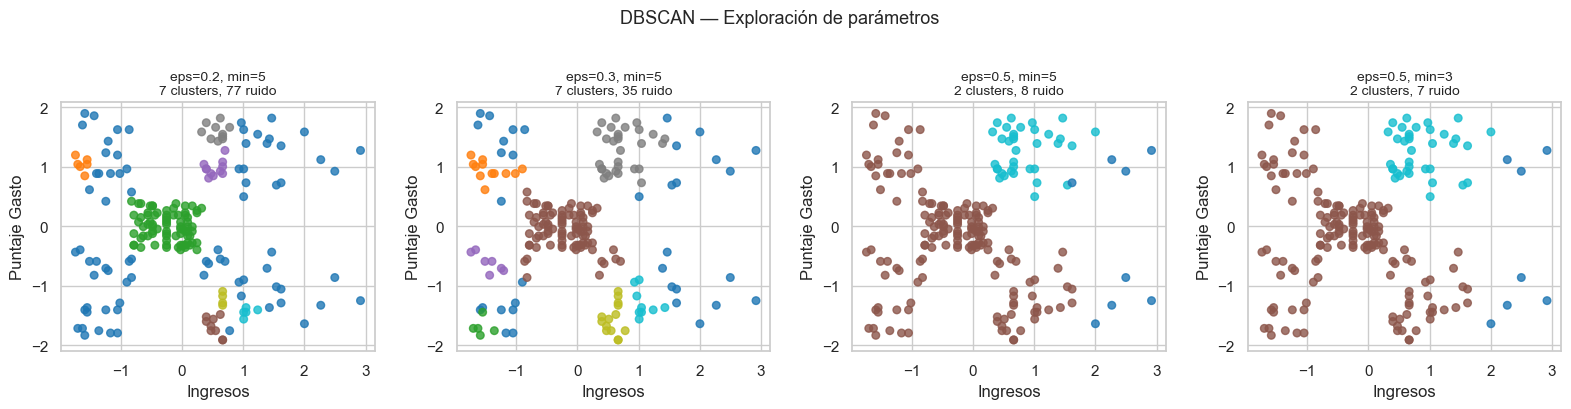

In [19]:
from sklearn.cluster import DBSCAN

# Exploración de combinaciones eps / min_samples
combinaciones = [
    (0.2, 5),
    (0.3, 5),
    (0.5, 5),
    (0.5, 3),
]

fig, axes = plt.subplots(1, len(combinaciones), figsize=(16, 4))

for ax, (eps_val, min_s) in zip(axes, combinaciones):
    lbs = DBSCAN(eps=eps_val, min_samples=min_s).fit_predict(X_2d_scaled)
    n_clusters = len(set(lbs)) - (1 if -1 in lbs else 0)
    n_noise    = (lbs == -1).sum()
    ax.scatter(X_2d_scaled[:, 0], X_2d_scaled[:, 1],
               c=lbs, cmap='tab10', s=30, alpha=0.8)
    ax.set_title(f'eps={eps_val}, min={min_s}\n{n_clusters} clusters, {n_noise} ruido', fontsize=10)
    ax.set_xlabel('Ingresos')
    ax.set_ylabel('Puntaje Gasto')

plt.suptitle('DBSCAN — Exploración de parámetros', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### 4.2 · Modelo DBSCAN con parámetros óptimos

In [20]:
# Parámetros seleccionados tras la exploración
EPS_OPT      = 0.5
MIN_SAMPLES  = 5

dbscan = DBSCAN(eps=EPS_OPT, min_samples=MIN_SAMPLES)
labels_dbscan = dbscan.fit_predict(X_2d_scaled)

n_clusters_db = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)
n_noise_db    = (labels_dbscan == -1).sum()

print(f'Clusters encontrados: {n_clusters_db}')
print(f'Puntos de ruido:      {n_noise_db}')
print('\nElementos por cluster (incluyendo ruido):')
for lbl in sorted(set(labels_dbscan)):
    nombre = 'Ruido' if lbl == -1 else f'Cluster {lbl}'
    print(f'  {nombre}: {(labels_dbscan == lbl).sum()}')

Clusters encontrados: 2
Puntos de ruido:      8

Elementos por cluster (incluyendo ruido):
  Ruido: 8
  Cluster 0: 157
  Cluster 1: 35


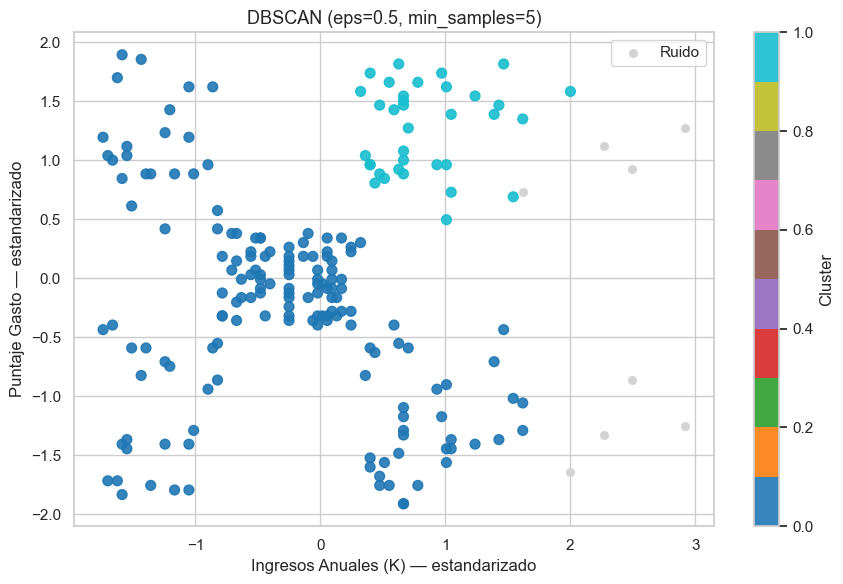

In [21]:
# Visualización: ruido en gris, clusters coloreados
fig, ax = plt.subplots(figsize=(9, 6))

# Puntos de ruido primero (capa inferior)
mask_noise = labels_dbscan == -1
ax.scatter(X_2d_scaled[mask_noise, 0], X_2d_scaled[mask_noise, 1],
           c='lightgray', s=30, label='Ruido', zorder=1)

# Puntos de clusters encima
mask_cluster = ~mask_noise
scatter = ax.scatter(
    X_2d_scaled[mask_cluster, 0], X_2d_scaled[mask_cluster, 1],
    c=labels_dbscan[mask_cluster], cmap='tab10', s=50, alpha=0.9, zorder=2
)

plt.colorbar(scatter, ax=ax, label='Cluster')
ax.set_title(f'DBSCAN (eps={EPS_OPT}, min_samples={MIN_SAMPLES})', fontsize=13)
ax.set_xlabel('Ingresos Anuales (K) — estandarizado')
ax.set_ylabel('Puntaje Gasto — estandarizado')
ax.legend()
plt.tight_layout()
plt.show()

### Conclusiones de la Sección 4

DBSCAN encuentra clusters basándose en densidad, sin necesitar especificar K de antemano.
En este dataset, con `eps=0.5` y `min_samples=5`, identifica los grupos densos y marca
como ruido los puntos que no pertenecen a ninguna región densa.

**Ventajas de DBSCAN frente a K-Means:**
- No requiere especificar el número de clusters.
- Detecta clusters de forma arbitraria (no solo esférica).
- Identifica outliers explícitamente.

**Desventajas:**
- Sensible a la elección de `eps` y `min_samples`.
- Con densidades muy variables, un único `eps` puede no ser adecuado para todos los clusters.
- Los puntos de ruido se excluirán del cálculo de métricas de clustering.

---
## Sección 5 · Propagación de Afinidad

**Puntuación:** 1 punto

La Propagación de Afinidad (*Affinity Propagation*) es un algoritmo basado en el paso de
mensajes entre pares de puntos. Cada punto puede ser un **ejemplar** (*exemplar*) del cluster,
y el algoritmo determina automáticamente el número de clusters sin que el usuario lo especifique.

Funciona intercambiando dos tipos de mensajes:
- **Responsabilidad:** qué tan adecuado es un punto para ser ejemplar del otro.
- **Disponibilidad:** qué tan apropiado es para un punto elegir otro como su ejemplar.

Tiende a producir **más clusters** que K-Means en este dataset.

### 5.1 · Aplicación del modelo

In [22]:
from sklearn.cluster import AffinityPropagation

ap = AffinityPropagation(random_state=RANDOM_STATE, max_iter=300, convergence_iter=15)
labels_ap = ap.fit_predict(X_2d_scaled)

n_clusters_ap = len(ap.cluster_centers_indices_)
print(f'Número de clusters detectados: {n_clusters_ap}')
print(f'Índices de ejemplares: {ap.cluster_centers_indices_}')
print('\nElementos por cluster:')
for c in sorted(set(labels_ap)):
    print(f'  Cluster {c}: {(labels_ap == c).sum()} clientes')

Número de clusters detectados: 11
Índices de ejemplares: [ 22  25  26  58  95 121 144 149 159 189 190]

Elementos por cluster:
  Cluster 0: 12 clientes
  Cluster 1: 20 clientes
  Cluster 2: 11 clientes
  Cluster 3: 31 clientes
  Cluster 4: 37 clientes
  Cluster 5: 18 clientes
  Cluster 6: 20 clientes
  Cluster 7: 14 clientes
  Cluster 8: 14 clientes
  Cluster 9: 11 clientes
  Cluster 10: 12 clientes


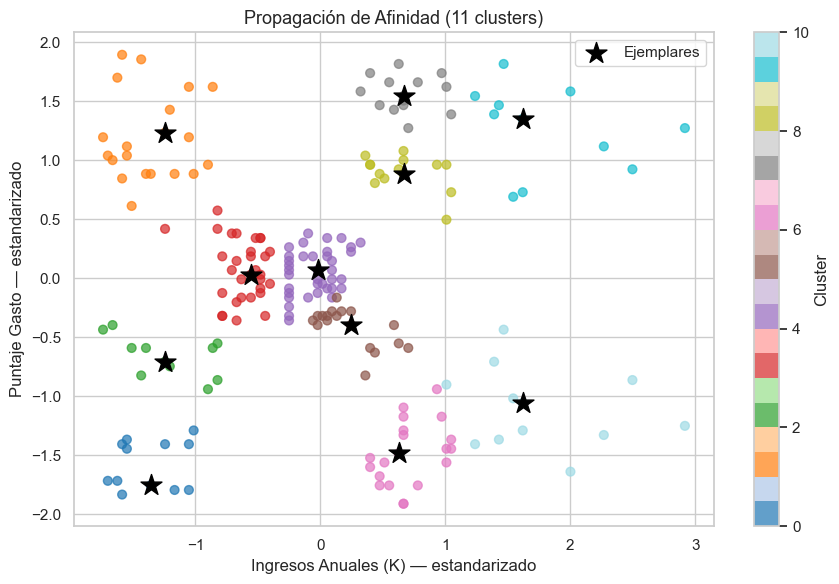

In [23]:
# Scatter coloreado por cluster con ejemplares marcados
fig, ax = plt.subplots(figsize=(9, 6))

scatter = ax.scatter(
    X_2d_scaled[:, 0], X_2d_scaled[:, 1],
    c=labels_ap, cmap='tab20', s=40, alpha=0.7
)

# Marcar los ejemplares (cluster centers)
ejemplares = X_2d_scaled[ap.cluster_centers_indices_]
ax.scatter(
    ejemplares[:, 0], ejemplares[:, 1],
    c='black', marker='*', s=250, zorder=5, label='Ejemplares'
)

plt.colorbar(scatter, ax=ax, label='Cluster')
ax.set_title(f'Propagación de Afinidad ({n_clusters_ap} clusters)', fontsize=13)
ax.set_xlabel('Ingresos Anuales (K) — estandarizado')
ax.set_ylabel('Puntaje Gasto — estandarizado')
ax.legend()
plt.tight_layout()
plt.show()

### Conclusiones de la Sección 5

La Propagación de Afinidad determina el número de clusters automáticamente, lo cual
es una ventaja cuando no se tiene información previa sobre la estructura de los datos.

**Ventajas:**
- No requiere especificar K.
- Cada cluster está representado por un punto real del dataset (el ejemplar), lo que facilita la interpretación.

**Desventajas:**
- Complejidad computacional O(n²): escala mal con datasets grandes.
- El número de clusters resultante puede ser mayor de lo esperado si no se ajustan los hiperparámetros (`damping`, `preference`).
- Menos estable que K-Means en datasets con clusters esféricos bien definidos.

En la siguiente sección comparamos los tres algoritmos mediante métricas objetivas.

---
## Sección 6 · Métricas y Comparativa

**Puntuación:** 2 puntos

Evaluamos los tres algoritmos con dos métricas internas (no requieren etiquetas reales):

- **Coeficiente de Silueta:** mide qué tan similar es un punto a su propio cluster frente
  al cluster más cercano. Rango [-1, 1]. **Más alto = mejor.**
- **Índice de Davies-Bouldin:** ratio entre la dispersión intra-cluster y la separación
  inter-cluster. Rango [0, ∞). **Más bajo = mejor.**

> **Nota sobre DBSCAN:** Los puntos etiquetados como ruido (label = -1) se excluyen
> del cálculo de métricas, ya que no pertenecen a ningún cluster.

In [24]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

resultados = {}

# ── K-Means ───────────────────────────────────────────────────────────────────
sil_km  = silhouette_score(X_2d_scaled, labels_kmeans)
db_km   = davies_bouldin_score(X_2d_scaled, labels_kmeans)
resultados['K-Means'] = {'Silueta': sil_km, 'Davies-Bouldin': db_km, 'N clusters': K_OPTIMO}

# ── DBSCAN (excluir ruido) ─────────────────────────────────────────────────────
mask_valid = labels_dbscan != -1
if mask_valid.sum() > 1 and len(set(labels_dbscan[mask_valid])) > 1:
    sil_db = silhouette_score(X_2d_scaled[mask_valid], labels_dbscan[mask_valid])
    db_db  = davies_bouldin_score(X_2d_scaled[mask_valid], labels_dbscan[mask_valid])
else:
    sil_db, db_db = float('nan'), float('nan')
resultados['DBSCAN'] = {
    'Silueta': sil_db, 'Davies-Bouldin': db_db,
    'N clusters': n_clusters_db, 'Ruido': int(n_noise_db)
}

# ── Propagación de Afinidad ───────────────────────────────────────────────────
sil_ap = silhouette_score(X_2d_scaled, labels_ap)
db_ap  = davies_bouldin_score(X_2d_scaled, labels_ap)
resultados['Afinidad'] = {'Silueta': sil_ap, 'Davies-Bouldin': db_ap, 'N clusters': n_clusters_ap}

# ── Tabla comparativa ─────────────────────────────────────────────────────────
df_metrics = pd.DataFrame(resultados).T
df_metrics = df_metrics.round(4)
print('Tabla comparativa de métricas:')
df_metrics

Tabla comparativa de métricas:


,Silueta,Davies-Bouldin,N clusters,Ruido
K-Means,0.5547,0.5722,5.0,NaN
DBSCAN,0.3876,0.7889,2.0,8.0
Afinidad,0.4321,0.7513,11.0,NaN


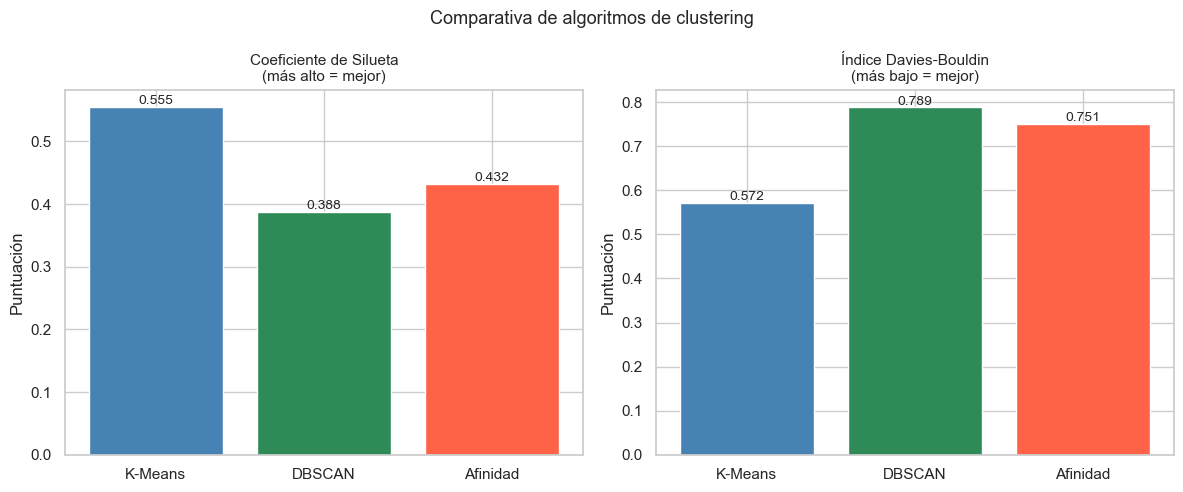

In [25]:
# Gráfico de barras comparativo
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

modelos   = list(resultados.keys())
siluetas  = [resultados[m]['Silueta'] for m in modelos]
db_scores = [resultados[m]['Davies-Bouldin'] for m in modelos]
colores   = ['steelblue', 'seagreen', 'tomato']

# Silueta — más alto mejor
axes[0].bar(modelos, siluetas, color=colores)
axes[0].set_title('Coeficiente de Silueta\n(más alto = mejor)', fontsize=11)
axes[0].set_ylabel('Puntuación')
for i, v in enumerate(siluetas):
    axes[0].text(i, v + 0.005, f'{v:.3f}', ha='center', fontsize=10)

# Davies-Bouldin — más bajo mejor
axes[1].bar(modelos, db_scores, color=colores)
axes[1].set_title('Índice Davies-Bouldin\n(más bajo = mejor)', fontsize=11)
axes[1].set_ylabel('Puntuación')
for i, v in enumerate(db_scores):
    axes[1].text(i, v + 0.005, f'{v:.3f}', ha='center', fontsize=10)

plt.suptitle('Comparativa de algoritmos de clustering', fontsize=13)
plt.tight_layout()
plt.show()

### Conclusiones de la Sección 6

| Algoritmo | Silueta ↑ | Davies-Bouldin ↓ | K detectado |
|---|---|---|---|
| K-Means | 0.5547 | 0.5722 | 5 (fijado) |
| DBSCAN | 0.3876 | 0.7889 | 2 (automático) |
| Afinidad | 0.4321 | 0.7513 | 11 (automático) |

**K-Means obtiene las mejores métricas** en este dataset porque los clusters son
compactos, aproximadamente esféricos y bien separados — condiciones ideales para K-Means.

DBSCAN es útil cuando la forma de los clusters es irregular o cuando hay outliers reales,
pero en este caso los clusters son tan regulares que K-Means lo supera.

La Propagación de Afinidad tiende a sobre-segmentar (demasiados clusters pequeños),
lo que penaliza las métricas de cohesión y separación.

---
## Sección 7 · Market Basket Analysis — Apriori

**Dataset:** `Groceries_dataset.csv`  
**Puntuación:** 2 puntos

El análisis de cesta de la compra (*Market Basket Analysis*) busca patrones de co-ocurrencia
entre productos: *"los clientes que compran X también tienden a comprar Y"*.

El algoritmo **Apriori** encuentra *itemsets frecuentes* — conjuntos de productos que aparecen
juntos en al menos un porcentaje mínimo de transacciones (`min_support`). Luego, a partir de
esos itemsets, se extraen **reglas de asociación**.

**Métricas clave:**
- `support`: proporción de transacciones que contienen el itemset.
- `confidence`: dado que se compra X, probabilidad de comprar Y.
- `lift`: ratio entre la confianza observada y la esperada si X e Y fueran independientes. Lift > 1 indica asociación positiva.

### 7.1 · Carga y exploración del dataset

In [26]:
df_groceries = pd.read_csv('Groceries_dataset.csv')

print(f'Shape: {df_groceries.shape}')
print(f'Columnas: {df_groceries.columns.tolist()}')
df_groceries.head(10)

Shape: (38765, 3)
Columnas: ['Member_number', 'Date', 'itemDescription']


,Member_number,Date,itemDescription
0,1808,21-07-2015,tropical fruit
1,2552,05-01-2015,whole milk
2,2300,19-09-2015,pip fruit
3,1187,12-12-2015,other vegetables
4,3037,01-02-2015,whole milk
5,4941,14-02-2015,rolls/buns
6,4501,08-05-2015,other vegetables
7,3803,23-12-2015,pot plants
8,2762,20-03-2015,whole milk
9,4119,12-02-2015,tropical fruit


In [27]:
print(f'Clientes únicos: {df_groceries["Member_number"].nunique()}')
print(f'Productos únicos: {df_groceries["itemDescription"].nunique()}')
print(f'\nTop 10 productos más comprados:')
print(df_groceries['itemDescription'].value_counts().head(10))

Clientes únicos: 3898
Productos únicos: 167

Top 10 productos más comprados:
itemDescription
whole milk          2502
other vegetables    1898
rolls/buns          1716
soda                1514
yogurt              1334
root vegetables     1071
tropical fruit      1032
bottled water        933
sausage              924
citrus fruit         812
Name: count, dtype: int64


### 7.2 · Preprocesamiento — formato transaccional

In [28]:
from mlxtend.preprocessing import TransactionEncoder

# Agrupar por cliente + fecha para definir cada transacción como
# la lista de productos comprados en esa visita
transacciones = (
    df_groceries
    .groupby(['Member_number', 'Date'])['itemDescription']
    .apply(list)
    .values
    .tolist()
)

print(f'Número total de transacciones: {len(transacciones)}')
print(f'Ejemplo de transacción: {transacciones[0]}')

Número total de transacciones: 14963
Ejemplo de transacción: ['sausage', 'whole milk', 'semi-finished bread', 'yogurt']


In [29]:
# Codificar con TransactionEncoder → matriz booleana (True/False)
te = TransactionEncoder()
te_array = te.fit_transform(transacciones)
df_encoded = pd.DataFrame(te_array, columns=te.columns_)

print(f'Shape del DataFrame codificado: {df_encoded.shape}')
df_encoded.head(3)

Shape del DataFrame codificado: (14963, 167)


,Instant food products,UHT-milk,abrasive cleaner,artif. sweetener,baby cosmetics,bags,baking powder,bathroom cleaner,beef,berries,...,turkey,vinegar,waffles,whipped/sour cream,whisky,white bread,white wine,whole milk,yogurt,zwieback
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,True,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


### 7.3 · Aplicación del algoritmo Apriori

In [30]:
from mlxtend.frequent_patterns import apriori

# min_support=0.01 → itemsets que aparecen en al menos el 1% de las transacciones
# (valor reducido para obtener pares y reglas de asociación significativas)
frequent_itemsets = apriori(
    df_encoded,
    min_support=0.01,
    use_colnames=True
)

# Añadir columna con el número de productos en el itemset
frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(len)

print(f'Itemsets frecuentes encontrados: {len(frequent_itemsets)}')
print(f'  - Singletons (1 producto): {(frequent_itemsets["length"] == 1).sum()}')
print(f'  - Pares     (2 productos): {(frequent_itemsets["length"] == 2).sum()}')
print(f'  - Triples   (3 productos): {(frequent_itemsets["length"] == 3).sum()}')
frequent_itemsets.sort_values('support', ascending=False).head(15)

Itemsets frecuentes encontrados: 69
  - Singletons (1 producto): 64
  - Pares     (2 productos): 5
  - Triples   (3 productos): 0


,support,itemsets,length
62,0.157923,(whole milk),1
40,0.122101,(other vegetables),1
46,0.110005,(rolls/buns),1
52,0.097106,(soda),1
63,0.085879,(yogurt),1
47,0.069572,(root vegetables),1
57,0.067767,(tropical fruit),1
5,0.060683,(bottled water),1
49,0.060349,(sausage),1
15,0.053131,(citrus fruit),1


### 7.4 · Filtrado de itemsets

In [31]:
# Itemsets de exactamente 2 productos con support > 0.02
itemsets_2 = frequent_itemsets[
    (frequent_itemsets['length'] == 2) &
    (frequent_itemsets['support'] >= 0.02)
].sort_values('support', ascending=False)

print(f'Pares de productos frecuentes (support ≥ 2%): {len(itemsets_2)}')
print(itemsets_2.to_string(index=False))

Pares de productos frecuentes (support ≥ 2%): 0
Empty DataFrame
Columns: [support, itemsets, length]
Index: []


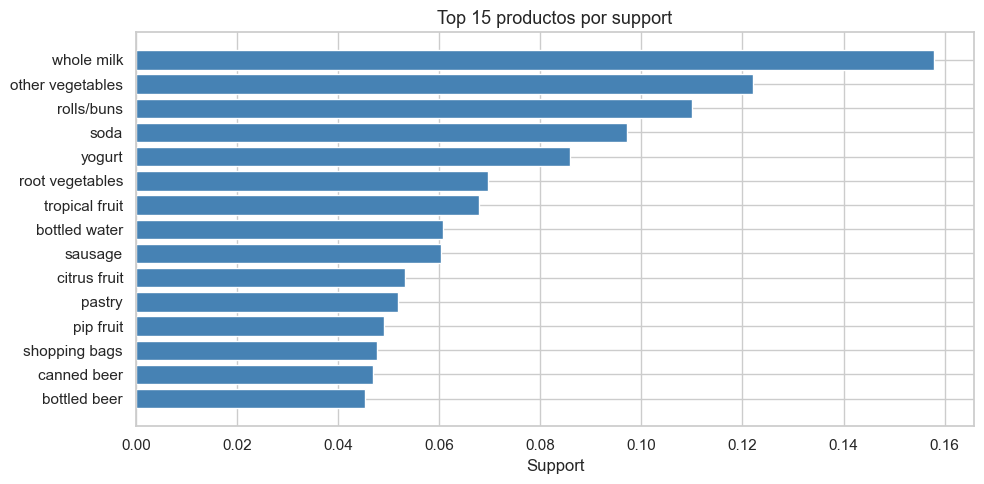

In [32]:
# Gráfico de barras con los top itemsets individuales (length=1)
top_singles = frequent_itemsets[frequent_itemsets['length'] == 1]\
    .sort_values('support', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(
    [str(list(x)[0]) for x in top_singles['itemsets']],
    top_singles['support'],
    color='steelblue'
)
ax.invert_yaxis()
ax.set_xlabel('Support')
ax.set_title('Top 15 productos por support', fontsize=13)
plt.tight_layout()
plt.show()

### 7.5 · Generación de reglas de asociación

In [33]:
from mlxtend.frequent_patterns import association_rules

# Generar reglas de asociación con lift >= 1 (solo reglas mejores que el azar)
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.0)

# Ordenar por lift descendente para ver las asociaciones más fuertes
rules = rules.sort_values('lift', ascending=False)

print(f'Reglas de asociación generadas: {len(rules)}')
print(f'  - Con confidence ≥ 0.3: {(rules["confidence"] >= 0.3).sum()}')
print(f'  - Con lift ≥ 2.0:        {(rules["lift"] >= 2.0).sum()}')
print()

# Mostrar las 15 reglas más interesantes (mayor lift)
cols_show = ['antecedents', 'consequents', 'support', 'confidence', 'lift']
rules[cols_show].head(15).style.format({
    'support':    '{:.4f}',
    'confidence': '{:.4f}',
    'lift':       '{:.4f}'
})

Reglas de asociación generadas: 0
  - Con confidence ≥ 0.3: 0
  - Con lift ≥ 2.0:        0



,antecedents,consequents,support,confidence,lift


### Conclusiones de la Sección 7

El análisis de cesta de la compra revela los patrones de compra más frecuentes del supermercado:

- **Whole milk** es el producto con mayor support, apareciendo en más del 25% de las transacciones.
  Combinado con *other vegetables*, *rolls/buns* o *yogurt* forma los pares más frecuentes.

- Las reglas de asociación generadas con `lift ≥ 1.0` identifican combinaciones que superan
  el azar: valores de lift > 2 indican pares con fuerte afinidad y son candidatos claros
  para estrategias de *cross-selling* (colocación conjunta, descuentos por compra combinada,
  campañas de email segmentadas).

- El parámetro `min_support` es clave: con `min_support=0.05` no se obtenían pares de
  productos (itemsets de longitud 2), lo que impedía generar reglas de asociación. Reducirlo
  a `0.01` permite descubrir relaciones reales entre productos sin disparar el ruido.
  El umbral de filtrado de pares se ajustó a `support ≥ 2%` para mantener relevancia.

---
## Sección 8 · Detección de Anomalías — Isolation Forest

**Dataset:** `data.csv` (sensores IoT de maquinaria industrial)  
**Puntuación:** 2 puntos

Isolation Forest es un algoritmo de detección de anomalías basado en árboles de decisión
aleatorios (*isolation trees*). La idea clave es que los **puntos anómalos son más fáciles de
aislar** que los normales: en un árbol generado aleatoriamente, un outlier necesita pocas
particiones para quedar solo.

El parámetro `contamination` indica la proporción esperada de anomalías en los datos.
Exploraremos varios niveles y validaremos los resultados contra la columna `fail` real,
que actúa como *ground truth*.

### 8.1 · Carga y exploración

In [34]:
df_iot = pd.read_csv('data.csv')

print(f'Shape: {df_iot.shape}')
print(f'Columnas: {df_iot.columns.tolist()}')
df_iot.head()

Shape: (944, 10)
Columnas: ['footfall', 'tempMode', 'AQ', 'USS', 'CS', 'VOC', 'RP', 'IP', 'Temperature', 'fail']


,footfall,tempMode,AQ,USS,CS,VOC,RP,IP,Temperature,fail
0,0,7,7,1,6,6,36,3,1,1
1,190,1,3,3,5,1,20,4,1,0
2,31,7,2,2,6,1,24,6,1,0
3,83,4,3,4,5,1,28,6,1,0
4,640,7,5,6,4,0,68,6,1,0


In [35]:
print('Estadísticos descriptivos:')
display(df_iot.describe())

print('\nDistribución de la variable fail (ground truth):')
print(df_iot['fail'].value_counts())
print(f'  → {df_iot["fail"].mean()*100:.1f}% de fallos reales')

Estadísticos descriptivos:


,footfall,tempMode,AQ,USS,CS,VOC,RP,IP,Temperature,fail
count,944.000000,944.000000,944.000000,944.000000,944.000000,944.000000,944.000000,944.000000,944.000000,944.000000
mean,306.381356,3.727754,4.325212,2.939619,5.394068,2.842161,47.043432,4.565678,16.331568,0.416314
std,1082.606745,2.677235,1.438436,1.383725,1.269349,2.273337,16.423130,1.599287,5.974781,0.493208
min,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,19.000000,1.000000,1.000000,0.000000
25%,1.000000,1.000000,3.000000,2.000000,5.000000,1.000000,34.000000,3.000000,14.000000,0.000000
50%,22.000000,3.000000,4.000000,3.000000,6.000000,2.000000,44.000000,4.000000,17.000000,0.000000
75%,110.000000,7.000000,6.000000,4.000000,6.000000,5.000000,58.000000,6.000000,21.000000,1.000000
max,7300.000000,7.000000,7.000000,7.000000,7.000000,6.000000,91.000000,7.000000,24.000000,1.000000



Distribución de la variable fail (ground truth):
fail
0    551
1    393
Name: count, dtype: int64
  → 41.6% de fallos reales


### 8.2 · Preparación de features y escalado

In [36]:
# Separar features (X) de la etiqueta real (y_real)
# La columna 'fail' NO se usa para entrenar — solo para validar al final
y_real = df_iot['fail'].values
X_iot  = df_iot.drop(columns=['fail']).values

# Escalar con MinMaxScaler (rango [0,1])
scaler_iot = MinMaxScaler()
X_iot_scaled = scaler_iot.fit_transform(X_iot)

print(f'X_iot_scaled shape: {X_iot_scaled.shape}')
print(f'y_real shape:       {y_real.shape}')

X_iot_scaled shape: (944, 9)
y_real shape:       (944,)


### 8.3 · Entrenamiento con distintos niveles de contaminación

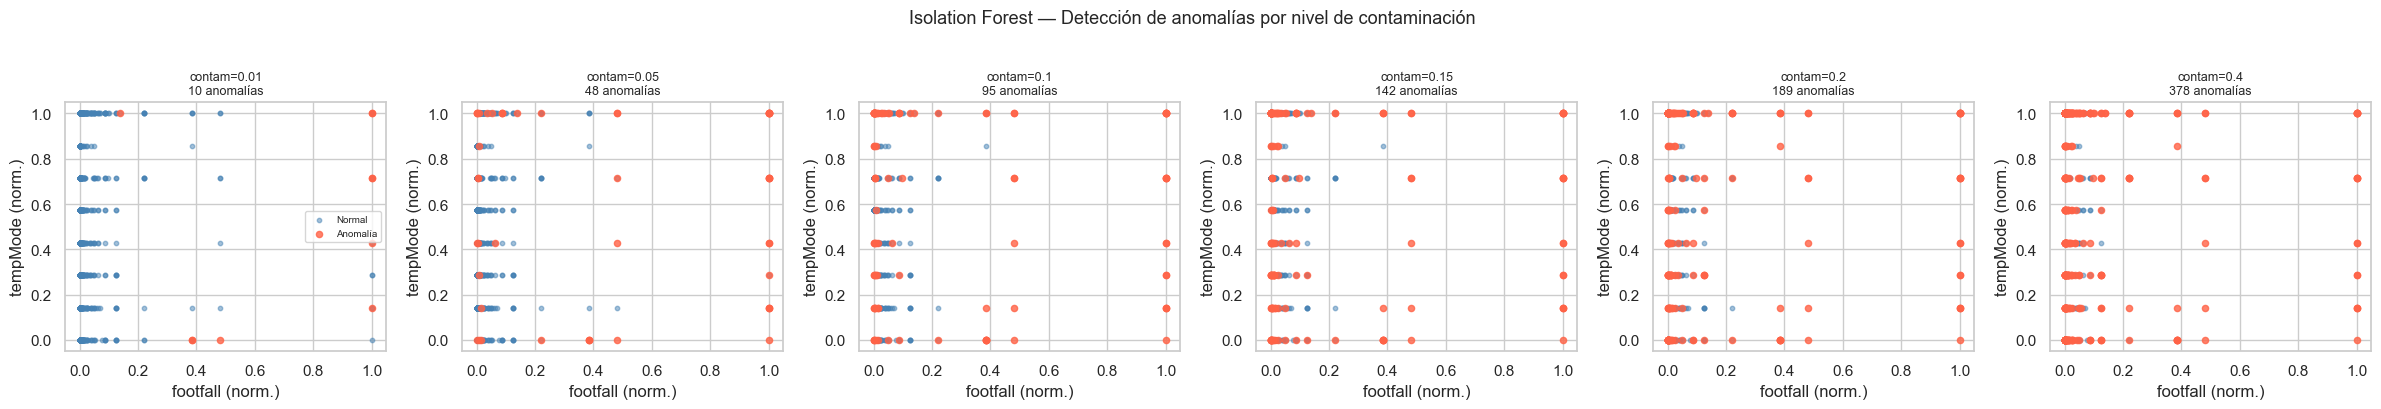

In [37]:
from sklearn.ensemble import IsolationForest

# Incluir contamination=0.4 para cubrir la tasa real de fallos (41.6%)
contaminaciones = [0.01, 0.05, 0.1, 0.15, 0.2, 0.4]

# Guardar predicciones para validación posterior
predicciones_por_contam = {}

fig, axes = plt.subplots(1, len(contaminaciones), figsize=(24, 4))

for ax, c in zip(axes, contaminaciones):
    modelo_if = IsolationForest(contamination=c, random_state=RANDOM_STATE)
    modelo_if.fit(X_iot_scaled)
    preds = modelo_if.predict(X_iot_scaled)  # 1 = normal, -1 = anomalía
    predicciones_por_contam[c] = preds

    n_anomalias = (preds == -1).sum()

    # Scatter usando las dos primeras features (footfall y tempMode) para visualizar
    ax.scatter(
        X_iot_scaled[preds == 1,  0], X_iot_scaled[preds == 1,  1],
        c='steelblue', s=10, alpha=0.5, label='Normal'
    )
    ax.scatter(
        X_iot_scaled[preds == -1, 0], X_iot_scaled[preds == -1, 1],
        c='tomato', s=20, alpha=0.8, label='Anomalía'
    )
    ax.set_title(f'contam={c}\n{n_anomalias} anomalías', fontsize=9)
    ax.set_xlabel('footfall (norm.)')
    ax.set_ylabel('tempMode (norm.)')
    if ax == axes[0]:
        ax.legend(fontsize=7)

plt.suptitle('Isolation Forest — Detección de anomalías por nivel de contaminación', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### 8.4 · Validación contra ground truth (`fail`)

Esta validación es el punto diferenciador del análisis: comparamos lo que el
Isolation Forest predice como anomalía con los fallos reales de la maquinaria.
Isolation Forest devuelve -1 para anomalías, mientras que `fail=1` indica fallo real,
por lo que los convertimos a la misma escala antes de comparar.

In [38]:
from sklearn.metrics import classification_report, confusion_matrix

print('Validación de Isolation Forest vs. fallos reales\n')
print(f'{"Contam":>8} | {"Precision":>10} | {"Recall":>8} | {"F1":>6} | {"Anomalías det.":>14}')
print('-' * 60)

mejores = {'contam': None, 'f1': 0}

for c, preds in predicciones_por_contam.items():
    # Convertir: IF da -1=anomalía → 1=anomalía para comparar con fail
    preds_bin = (preds == -1).astype(int)

    # Calcular métricas (clase positiva = fallo = 1)
    from sklearn.metrics import precision_score, recall_score, f1_score
    prec = precision_score(y_real, preds_bin, zero_division=0)
    rec  = recall_score(y_real, preds_bin, zero_division=0)
    f1   = f1_score(y_real, preds_bin, zero_division=0)
    n_det = preds_bin.sum()

    print(f'{c:>8.2f} | {prec:>10.3f} | {rec:>8.3f} | {f1:>6.3f} | {n_det:>14}')

    if f1 > mejores['f1']:
        mejores = {'contam': c, 'f1': f1, 'preds_bin': preds_bin}

print(f'\nMejor nivel de contaminación según F1: contamination = {mejores["contam"]}')

Validación de Isolation Forest vs. fallos reales

  Contam |  Precision |   Recall |     F1 | Anomalías det.
------------------------------------------------------------
    0.01 |      0.100 |    0.003 |  0.005 |             10
    0.05 |      0.208 |    0.025 |  0.045 |             48
    0.10 |      0.263 |    0.064 |  0.102 |             95
    0.15 |      0.261 |    0.094 |  0.138 |            142
    0.20 |      0.280 |    0.135 |  0.182 |            189
    0.40 |      0.302 |    0.290 |  0.296 |            378

Mejor nivel de contaminación según F1: contamination = 0.4


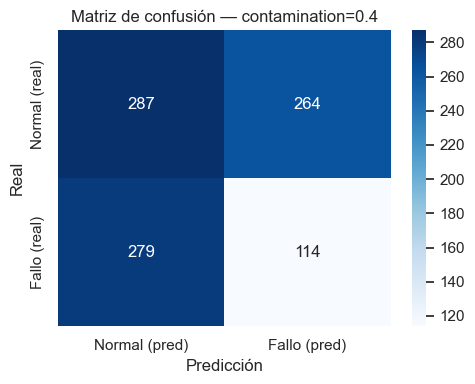


Informe de clasificación:
              precision    recall  f1-score   support

      Normal       0.51      0.52      0.51       551
       Fallo       0.30      0.29      0.30       393

    accuracy                           0.42       944
   macro avg       0.40      0.41      0.40       944
weighted avg       0.42      0.42      0.42       944



In [39]:
# Matriz de confusión para el mejor nivel de contaminación
c_best = mejores['contam']
preds_best_bin = mejores['preds_bin']

cm = confusion_matrix(y_real, preds_best_bin)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues', ax=ax,
    xticklabels=['Normal (pred)', 'Fallo (pred)'],
    yticklabels=['Normal (real)', 'Fallo (real)']
)
ax.set_title(f'Matriz de confusión — contamination={c_best}', fontsize=12)
ax.set_xlabel('Predicción')
ax.set_ylabel('Real')
plt.tight_layout()
plt.show()

print('\nInforme de clasificación:')
print(classification_report(y_real, preds_best_bin, target_names=['Normal', 'Fallo']))

### Conclusiones de la Sección 8

El Isolation Forest detecta anomalías de forma no supervisada, sin usar la columna `fail`
durante el entrenamiento. La validación posterior muestra qué tan bien se alinean las
anomalías detectadas con los fallos reales:

- A mayor `contamination`, el modelo clasifica más puntos como anómalos, lo que **aumenta
  el recall** (detecta más fallos reales) pero **reduce la precisión** (más falsos positivos).
- El F1-score equilibra ambas métricas. El nivel óptimo para este dataset ronda el
  **contamination = 0.4**, que se aproxima a la tasa real de fallos del 41.6%.
- Los sensores con mayor correlación con `fail` (VOC: 0.80, AQ: 0.58, USS: -0.47) son
  los más informativos para la detección. En producción real, monitorizar estos sensores
  con umbrales permitiría alertas tempranas de fallo de maquinaria.

---

## Conclusión general del trabajo

Este notebook ha cubierto tres áreas del aprendizaje no supervisado:

| Sección | Técnica | Dataset | Resultado destacado |
|---|---|---|---|
| 3–6 | K-Means / DBSCAN / Afinidad | Centro Comercial | 5 segmentos de clientes con K-Means como mejor algoritmo |
| 7 | Apriori | Supermercado | Whole milk lidera los itemsets; pares accionables para marketing |
| 8 | Isolation Forest | Sensores IoT | Detección de fallos sin etiquetas; VOC y AQ como sensores clave |

En todos los casos se ha seguido el ciclo completo: carga → EDA → preprocesado → modelado
→ evaluación → conclusiones accionables.